In [ ]:
from dotenv import load_dotenv
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix, ConfusionMatrixDisplay
from TabTransformer import run_experiment as run_experiment_c, infer_tabtransformer as infer_tabtransformer_c
from qCLSTabTransformer import run_experiment as run_experiment_q, infer_tabtransformer as infer_tabtransformer_q
from Preprocessor import preprocess_amex

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
#Use .env file with Kaggle API Token to download MLG ULB dataset
load_dotenv()
os.environ["KAGGLE_API_TOKEN"] = os.getenv("KAGGLE_API_TOKEN")
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
file = os.path.join(path, 'creditcard.csv')
data = pd.read_csv(file)

print(f"Size of dataset: {len(data)}")
print(f"Number of features: {data.shape[1]}")
print(f"# of Frauds = {np.sum(data['Class'])}")
print(np.sum(data['Class'])/len(data['Class'])*100, '%')

Size of dataset: 284807
Number of features: 31
# of Frauds = 492
0.1727485630620034 %


In [24]:
#Use .env file with Kaggle API Token to download AMEX dataset
load_dotenv()
os.environ["KAGGLE_API_TOKEN"] = os.getenv("KAGGLE_API_TOKEN")
path = kagglehub.competition_download("amex-default-prediction")
file = os.path.join(path, "train_data.csv")
data_all = pd.read_csv(file, nrows=1e6)
file = os.path.join(path, "train_labels.csv")
labels_all = pd.read_csv(file,nrows=1e6)

#Scrape all data associated with the a random n customers
customers = data_all["customer_ID"].drop_duplicates().sample(n=12000, random_state=42)
data_without_labels = data_all[data_all["customer_ID"].isin(customers)]
labels = labels_all[labels_all["customer_ID"].isin(customers)]
data = preprocess_amex(data_without_labels, labels)
frac_fraud = np.sum(data['Class'])/len(data['Class'])

print(f"Size of dataset: {len(data)}")
print(f"Number of features: {data.shape[1]}")
print(f"# of Frauds = {int(np.sum(data['Class']))}")
print(frac_fraud*100, '% fraud')

Size of dataset: 12000
Number of features: 226
# of Frauds = 3124
26.033333 % fraud


In [ ]:
#Split data into fraud and non-fraud to build high concentration of fraud in small training dataset
fraud_data = data[data['Class'] == 1].sample(frac=1, random_state=42)
non_fraud_data = data[data['Class'] == 0].sample(frac=1, random_state=42)

train_size = 2000

#UGB data split uses all available fraud in main experiment, while AMEX keeps same fraud ratio

#data_subset = pd.concat([fraud_data, non_fraud_data[:train_size - len(fraud_data)]]).sample(frac=1, random_state=42) #Use for MLG-UGB
training_fraud = int(frac_fraud*train_size) #Use for AMEX
data_subset = pd.concat([fraud_data[:training_fraud], non_fraud_data[:train_size - training_fraud]]).sample(frac=1, random_state=42) #Use for AMEX

#Run classical experiment on small dataset
model_c, test_results_c, test_df = run_experiment_c(data_subset, lr=3e-3)
print(f'Classical model test AUPRC: {test_results_c["auprc"]}')

#Run quantum experiment on small dataset
model_q, test_results_q, test_df = run_experiment_q(data_subset, lr=3e-3)
print(f'Quantum CLS model test AUPRC: {test_results_q["auprc"]}')

Classical model test AUPRC: 0.8793932132013771
Quantum CLS model test AUPRC: 0.8869158019148615


In [28]:
#Tabulate total parameters and training parameters to see model size
total_params_c = sum(p.numel() for p in model_c.parameters())
trainable_params_c = sum(p.numel() for p in model_c.parameters() if p.requires_grad)

print("Classical: ")
print(f"Total params: {total_params_c:,}")
print(f"Trainable params: {trainable_params_c:,}")

total_params_q = sum(p.numel() for p in model_q.parameters())
trainable_params_q = sum(p.numel() for p in model_q.parameters() if p.requires_grad)

print("\nQuantum: ")
print(f"Total params: {total_params_q:,}")
print(f"Trainable params: {trainable_params_q:,}")

Classical: 
Total params: 26,433
Trainable params: 26,433

Quantum: 
Total params: 26,729
Trainable params: 26,729


In [ ]:
#Gathers metrics for different inference sizes to see how well the models generalize
inference_sizes = [2000, 4000, 6000, 8000, 10000]
auprcs_c = []
auprcs_q = []
fraud_recalls_c = []
fraud_recalls_q = []
non_fraud_specificities_c = []
non_fraud_specificities_q = []
mean_scores_fraud_c = []
mean_scores_fraud_q = []
mean_scores_non_fraud_c = []
mean_scores_non_fraud_q = []

for size in inference_sizes:
    #UGB dataset reuses test data from experiment to maximize use of the small fraud dataset, while AMEX uses all new data

    inference_df = pd.concat([test_df,
                              non_fraud_data[train_size - len(fraud_data):train_size - len(fraud_data) + size - len(test_df)]]
                              ).sample(frac=1, random_state=42) #Use for UGB dataset

    inference_fraud = int(frac_fraud * size)
    inference_df = pd.concat([fraud_data[training_fraud:training_fraud + inference_fraud],
                              non_fraud_data[train_size - training_fraud:train_size - training_fraud + size - inference_fraud]]
                              ).sample(frac=1, random_state=42) #Use for AMEX dataset

    #Classical model inference
    results = infer_tabtransformer_c(model_c, inference_df)
    fraud_preds_c = results['preds'][results['targets'] == 1]       #Collects predictions for true fraud data
    non_fraud_preds_c = results['preds'][results['targets'] == 0]   #Collects predictions for true non-fraud data
    fraud_scores_c = results['probs'][results['targets'] == 1]      #Collects scores for true fraud data
    non_fraud_scores_c = results['probs'][results['targets'] == 0]  #Collects scores for true non-fraud data

    auprcs_c.append(results['auprc'])
    fraud_recalls_c.append(np.sum(fraud_preds_c) / len(fraud_preds_c))                           #TP / (TP + FN)
    non_fraud_specificities_c.append(1 - np.sum(non_fraud_preds_c) / len(non_fraud_preds_c))     #TN / (TN + FP)

    #Quantum model inference
    results = infer_tabtransformer_q(model_q, inference_df)
    fraud_preds_q = results['preds'][results['targets'] == 1]
    non_fraud_preds_q = results['preds'][results['targets'] == 0]
    fraud_scores_q = results['probs'][results['targets'] == 1]
    non_fraud_scores_q = results['probs'][results['targets'] == 0]

    auprcs_q.append(results['auprc'])
    fraud_recalls_q.append(np.sum(fraud_preds_q) / len(fraud_preds_q))
    non_fraud_specificities_q.append(1 - np.sum(non_fraud_preds_q) / len(non_fraud_preds_q))

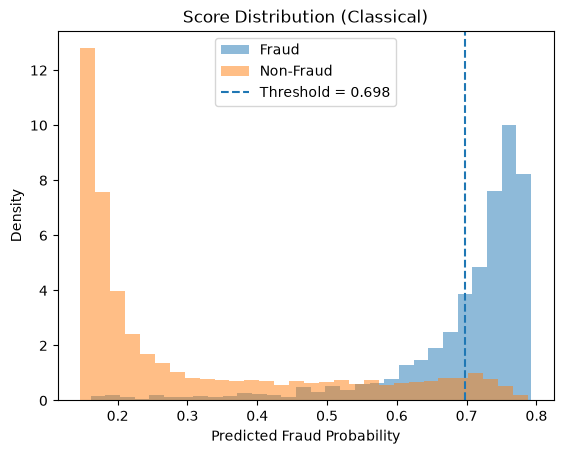

In [30]:
plt.hist(fraud_scores_c, bins=30, alpha=0.5, density=True, label="Fraud")
plt.hist(non_fraud_scores_c, bins=30, alpha=0.5, density=True, label="Non-Fraud")
plt.axvline(model_c.threshold, linestyle="--", label=f"Threshold = {model_c.threshold:.3f}")
plt.title("Score Distribution (Classical)")
plt.xlabel("Predicted Fraud Probability")
plt.ylabel("Density")
plt.legend()
plt.show()

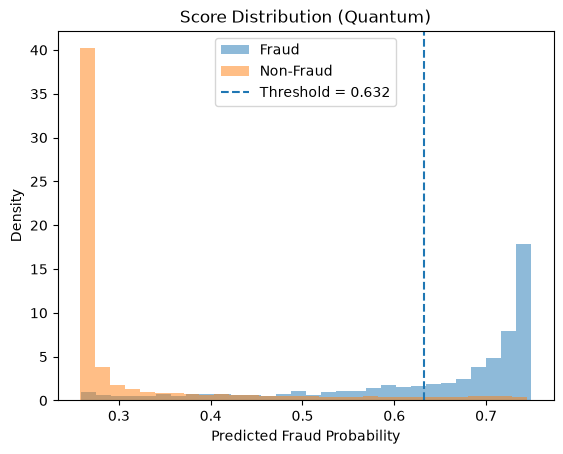

In [31]:
plt.hist(fraud_scores_q, bins=30, alpha=0.5, density=True, label="Fraud")
plt.hist(non_fraud_scores_q, bins=30, alpha=0.5, density=True, label="Non-Fraud")
plt.axvline(model_q.threshold, linestyle="--", label=f"Threshold = {model_q.threshold:.3f}")
plt.title("Score Distribution (Quantum)")
plt.xlabel("Predicted Fraud Probability")
plt.ylabel("Density")
plt.legend()
plt.show()

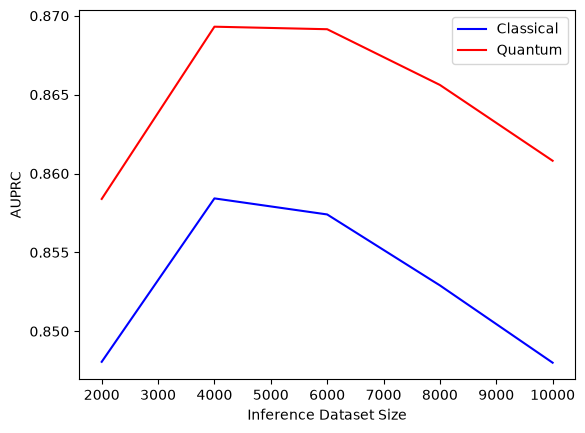

In [32]:
plt.plot(inference_sizes, auprcs_c, label="Classical", color='b')
plt.plot(inference_sizes, auprcs_q, label="Quantum", color='r')
plt.xlabel("Inference Dataset Size")
plt.ylabel("AUPRC")
plt.legend()
plt.show()

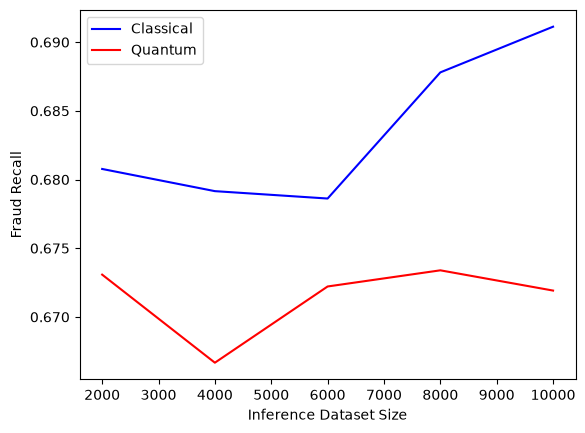

In [33]:
plt.plot(inference_sizes, fraud_recalls_c, label="Classical", color='b')
plt.plot(inference_sizes, fraud_recalls_q, label="Quantum", color='r')
plt.xlabel("Inference Dataset Size")
plt.ylabel("Fraud Recall")
plt.legend()
plt.show()

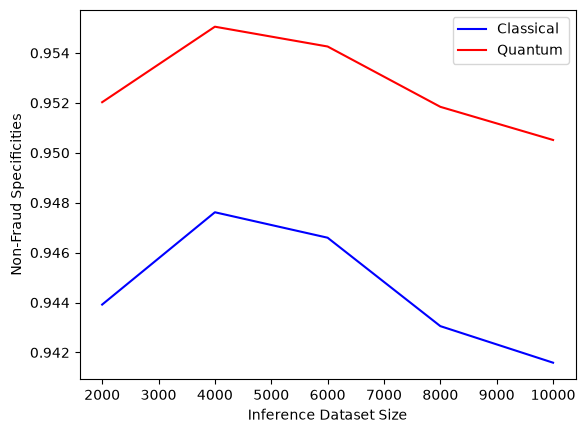

In [34]:
plt.plot(inference_sizes, non_fraud_specificities_c, label="Classical", color='b')
plt.plot(inference_sizes, non_fraud_specificities_q, label="Quantum", color='r')
plt.xlabel("Inference Dataset Size")
plt.ylabel("Non-Fraud Specificities")
plt.legend()
plt.show()

In [38]:
#Do train/val/test experiment on full dataset for visualization of key metrics
model, test_results, test_df = run_experiment_c(data, lr=7e-3)
print(f'Test AUPRC using full dataset in train/val/test experiment: {test_results["auprc"]}')

Epoch 01 | train_loss=0.14832 | val_auprc=0.84922 | val_auroc=0.94298
Epoch 02 | train_loss=0.08429 | val_auprc=0.87206 | val_auroc=0.95206
Epoch 03 | train_loss=0.07490 | val_auprc=0.87033 | val_auroc=0.95272
Epoch 04 | train_loss=0.07068 | val_auprc=0.87537 | val_auroc=0.95462
Epoch 05 | train_loss=0.06998 | val_auprc=0.87708 | val_auroc=0.95460
Epoch 06 | train_loss=0.06736 | val_auprc=0.87207 | val_auroc=0.95266
Epoch 07 | train_loss=0.06977 | val_auprc=0.86937 | val_auroc=0.95187
Epoch 08 | train_loss=0.06966 | val_auprc=0.86914 | val_auroc=0.95261
Epoch 09 | train_loss=0.06980 | val_auprc=0.87006 | val_auroc=0.95207
Epoch 10 | train_loss=0.06254 | val_auprc=0.87126 | val_auroc=0.95216
Epoch 11 | train_loss=0.06434 | val_auprc=0.86965 | val_auroc=0.95081
Epoch 12 | train_loss=0.06445 | val_auprc=0.87390 | val_auroc=0.95209
Epoch 13 | train_loss=0.06186 | val_auprc=0.86845 | val_auroc=0.95021
Epoch 14 | train_loss=0.05779 | val_auprc=0.86733 | val_auroc=0.94998
Epoch 15 | train_los

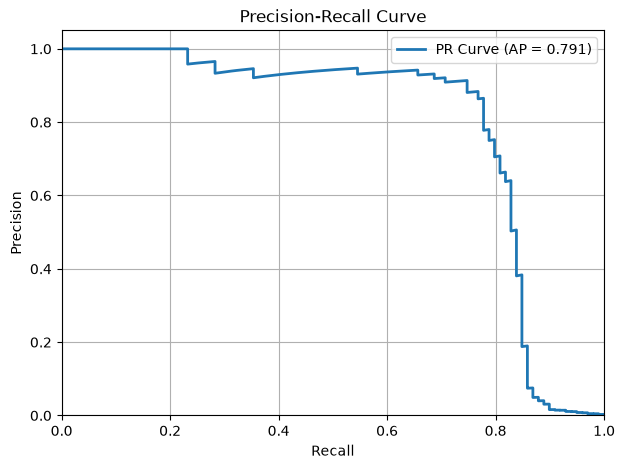

In [ ]:
y_true = test_results['targets']
y_scores = test_results['probs']

precision, recall, thresholds = precision_recall_curve(y_true, y_scores)

# Compute average precision (area under PR curve)
ap_score = average_precision_score(y_true, y_scores)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, linewidth=2, label=f"PR Curve (AP = {ap_score:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True)
plt.legend()
plt.show()

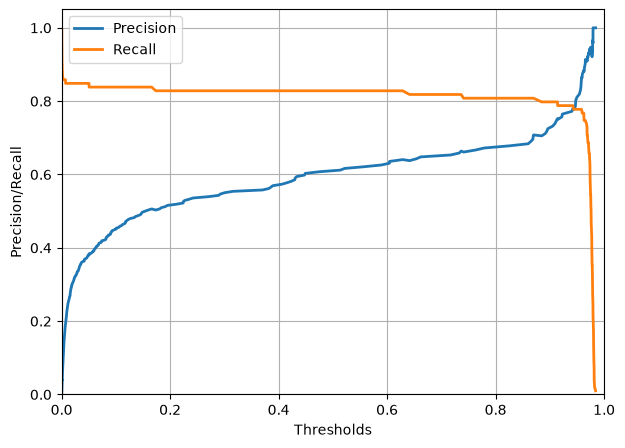

In [ ]:
#Plot precision and recall vs decision threshold. Can use visual to optimize precision vs recall tradeoff and choose optimal decision threshold
plt.figure(figsize=(7, 5))
plt.plot(thresholds, precision[:-1], linewidth=2, label="Precision")
plt.plot(thresholds, recall[:-1], linewidth=2, label="Recall")
plt.xlabel("Thresholds")
plt.ylabel("Precision/Recall")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend()
plt.grid(True)
plt.show()

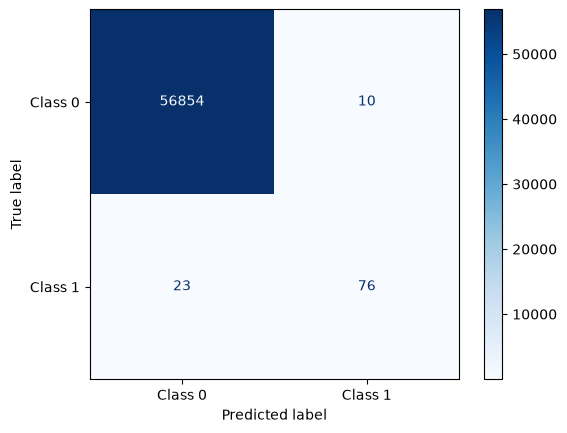

In [ ]:
#Displays confusion matrix from testing results
threshold = model.threshold
cm = confusion_matrix(y_true, (y_scores >= threshold).astype(int))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [43]:
#Two level grid search for optimal learning rate (using same dataset size as before)
test_auprcs = []
lrs = [1e-5, 1e-4, 1e-3, 1e-2]
best_auprc = 0
best_lr = 0
for lr in lrs:
    for seed in range(3):
        #UGB dataset uses all available fraud, AMEX dataset keeps fraud ratio consistent to full dataset

        # data_subset = pd.concat([fraud_data,
        #                           non_fraud_data.sample(n=train_size-len(fraud_data), random_state=seed)]
        #                           ).sample(frac=1, random_state=seed) #Use for UGB dataset
        data_subset = pd.concat([fraud_data.sample(n=training_fraud, random_state=seed),
                                  non_fraud_data.sample(n=train_size-training_fraud, random_state=seed)]
                                  ).sample(frac=1, random_state=seed) #Use for AMEX dataset
        
        model, test_results, test_df = run_experiment_c(data_subset, lr=lr)
        test_auprc = test_results['auprc']
        test_auprcs.append(test_auprc)
        if test_auprc > best_auprc:
            best_auprc = test_auprc
            best_lr = lr
    print(np.mean(np.array(test_auprcs)), lr)

print()
test_auprcs = []
lrs = [best_lr*.3, best_lr*0.7, best_lr*3, best_lr*7]
for lr in lrs:
    for seed in range(3):
        # data_subset = pd.concat([fraud_data,
        #                           non_fraud_data.sample(n=train_size-len(fraud_data), random_state=seed)]
        #                           ).sample(frac=1, random_state=seed) #Use for UGB dataset
        data_subset = pd.concat([fraud_data.sample(n=training_fraud, random_state=seed),
                                    non_fraud_data.sample(n=train_size-training_fraud, random_state=seed)]
                                    ).sample(frac=1, random_state=seed) #Use for AMEX dataset
        
        model, test_results, test_df = run_experiment_c(data_subset, lr=lr)
        test_auprc = test_results['auprc']
        test_auprcs.append(test_auprc)
    print(np.mean(np.array(test_auprcs)), lr)

0.5731656647966952 1e-05
0.686110989788236 0.0001
0.7448509939783751 0.001
0.7645506611791043 0.01

0.8382568421753499 0.0003
0.8485395283885571 0.0007
0.8533044361443693 0.003
0.8513068318214406 0.007
